In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [21]:
import os
import random
import warnings

import librosa
import librosa.display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [23]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

print(mixed_precision.global_policy())

<DTypePolicy "mixed_float16">


In [24]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [25]:
DATASET_PATH = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original"

genres = sorted(os.listdir(DATASET_PATH))

print(genres)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [26]:
genre_counts = {}

for genre in genres:

    folder = os.path.join(DATASET_PATH, genre)

    genre_counts[genre] = len(os.listdir(folder))

pd.DataFrame.from_dict(
    genre_counts,
    orient="index",
    columns=["Songs"]
)

,Songs
blues,100
classical,100
country,100
disco,100
hiphop,100
jazz,100
metal,100
pop,100
reggae,100
rock,100


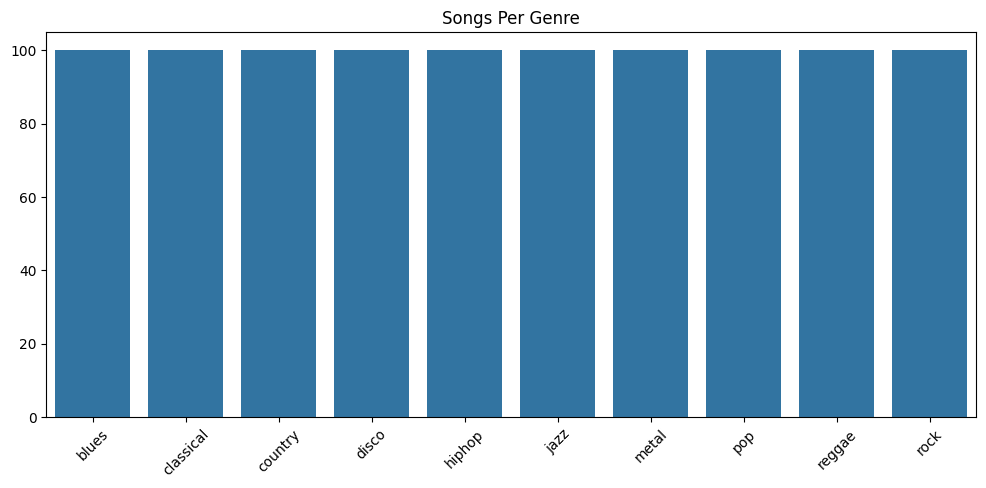

In [27]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=list(genre_counts.keys()),
    y=list(genre_counts.values())
)

plt.xticks(rotation=45)

plt.title("Songs Per Genre")

plt.show()

In [28]:
paths = []
labels = []

for genre in genres:

    folder = os.path.join(DATASET_PATH, genre)

    for file in os.listdir(folder):

        if file.endswith(".wav"):

            paths.append(os.path.join(folder,file))

            labels.append(genre)

df = pd.DataFrame({

    "path":paths,

    "label":labels

})

df.head()

,path,label
0,/kaggle/input/datasets/andradaolteanu/gtzan-da...,blues
1,/kaggle/input/datasets/andradaolteanu/gtzan-da...,blues
2,/kaggle/input/datasets/andradaolteanu/gtzan-da...,blues
3,/kaggle/input/datasets/andradaolteanu/gtzan-da...,blues
4,/kaggle/input/datasets/andradaolteanu/gtzan-da...,blues


In [29]:
print(df.shape)

print(df.label.value_counts())

df.sample(10)

(1000, 2)
label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


,path,label
521,/kaggle/input/datasets/andradaolteanu/gtzan-da...,jazz
737,/kaggle/input/datasets/andradaolteanu/gtzan-da...,pop
740,/kaggle/input/datasets/andradaolteanu/gtzan-da...,pop
660,/kaggle/input/datasets/andradaolteanu/gtzan-da...,metal
411,/kaggle/input/datasets/andradaolteanu/gtzan-da...,hiphop
678,/kaggle/input/datasets/andradaolteanu/gtzan-da...,metal
626,/kaggle/input/datasets/andradaolteanu/gtzan-da...,metal
513,/kaggle/input/datasets/andradaolteanu/gtzan-da...,jazz
859,/kaggle/input/datasets/andradaolteanu/gtzan-da...,reggae
136,/kaggle/input/datasets/andradaolteanu/gtzan-da...,classical


In [31]:
from IPython.display import Audio

sample = df.iloc[513]["path"]

Audio(sample)

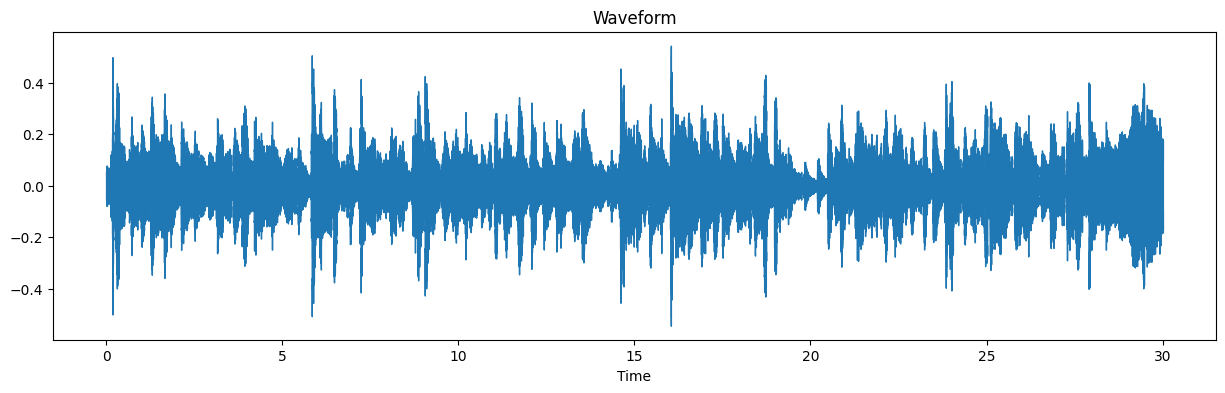

In [32]:
y, sr = librosa.load(sample, sr=22050)

plt.figure(figsize=(15,4))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform")

plt.show()

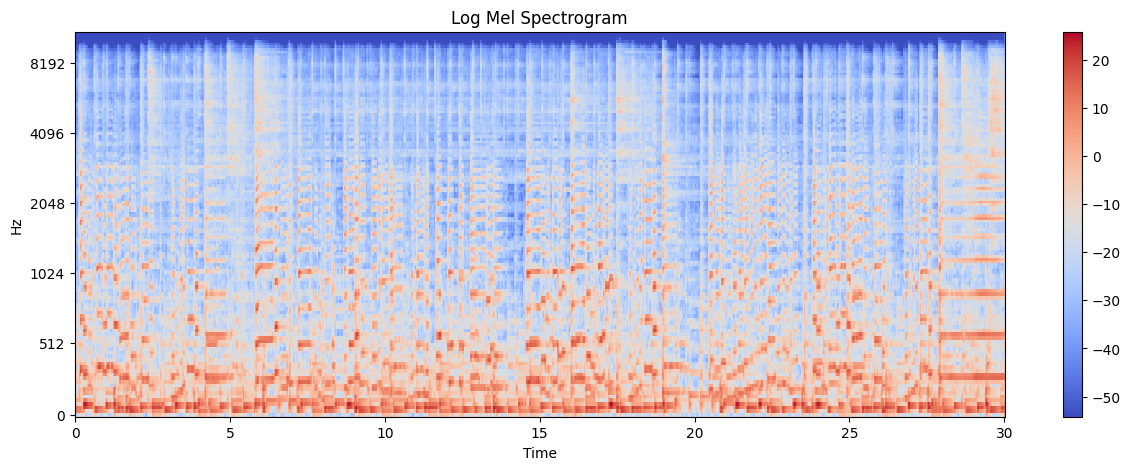

In [33]:
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(15,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Log Mel Spectrogram")

plt.show()

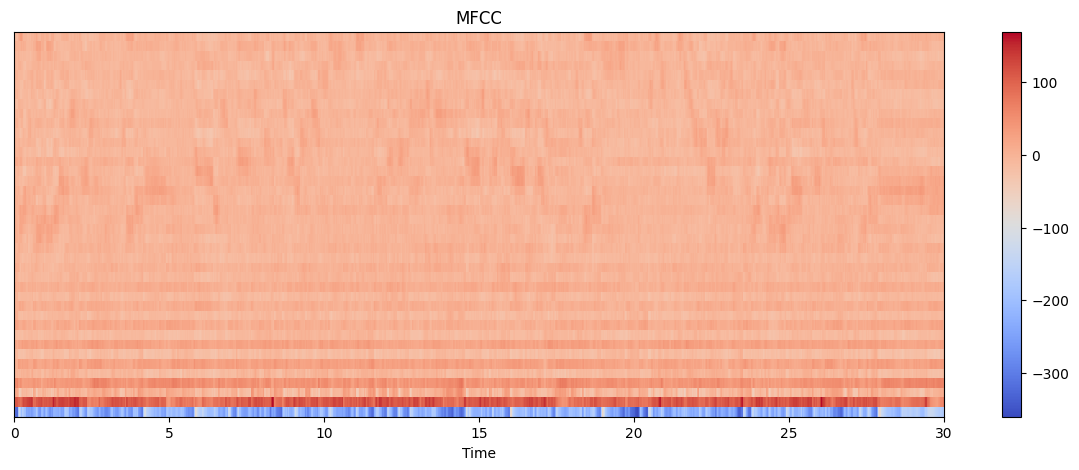

In [34]:
#MFCC VISUALIZATION
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=40
)

plt.figure(figsize=(15,5))

librosa.display.specshow(
    mfcc,
    x_axis="time"
)

plt.colorbar()

plt.title("MFCC")

plt.show()

In [35]:
#LABEL ENCODING
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label_encoded"] = encoder.fit_transform(df["label"])

print(df.head())

                                                path  label  label_encoded
0  /kaggle/input/datasets/andradaolteanu/gtzan-da...  blues              0
1  /kaggle/input/datasets/andradaolteanu/gtzan-da...  blues              0
2  /kaggle/input/datasets/andradaolteanu/gtzan-da...  blues              0
3  /kaggle/input/datasets/andradaolteanu/gtzan-da...  blues              0
4  /kaggle/input/datasets/andradaolteanu/gtzan-da...  blues              0


In [36]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:",len(train_df))
print("Validation:",len(val_df))
print("Test:",len(test_df))

Train: 800
Validation: 100
Test: 100


In [37]:
print(train_df.label.value_counts())

print()

print(val_df.label.value_counts())

print()

print(test_df.label.value_counts())

label
jazz         80
country      80
rock         80
hiphop       80
pop          80
reggae       80
metal        80
blues        80
classical    80
disco        80
Name: count, dtype: int64

label
disco        10
jazz         10
classical    10
hiphop       10
blues        10
country      10
rock         10
metal        10
pop          10
reggae       10
Name: count, dtype: int64

label
metal        10
classical    10
jazz         10
reggae       10
rock         10
disco        10
pop          10
hiphop       10
blues        10
country      10
Name: count, dtype: int64


In [38]:
print(train_df.label.value_counts())

print()

print(val_df.label.value_counts())

print()

print(test_df.label.value_counts())

label
jazz         80
country      80
rock         80
hiphop       80
pop          80
reggae       80
metal        80
blues        80
classical    80
disco        80
Name: count, dtype: int64

label
disco        10
jazz         10
classical    10
hiphop       10
blues        10
country      10
rock         10
metal        10
pop          10
reggae       10
Name: count, dtype: int64

label
metal        10
classical    10
jazz         10
reggae       10
rock         10
disco        10
pop          10
hiphop       10
blues        10
country      10
Name: count, dtype: int64


In [39]:
classes=np.unique(train_df["label_encoded"])

weights=compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_encoded"]
)

class_weights=dict(zip(classes,weights))

print(class_weights)

{np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0), np.int64(3): np.float64(1.0), np.int64(4): np.float64(1.0), np.int64(5): np.float64(1.0), np.int64(6): np.float64(1.0), np.int64(7): np.float64(1.0), np.int64(8): np.float64(1.0), np.int64(9): np.float64(1.0)}


In [40]:
import librosa

def augment_audio(audio,sr):

    if np.random.rand()<0.5:
        audio=librosa.effects.time_stretch(audio,rate=np.random.uniform(0.8,1.2))

    if np.random.rand()<0.5:
        audio=librosa.effects.pitch_shift(
            audio,
            sr=sr,
            n_steps=np.random.randint(-2,3)
        )

    if np.random.rand()<0.5:

        noise=np.random.randn(len(audio))

        audio=audio+0.003*noise

    return audio

In [41]:
IMG_SIZE=224

def create_spectrogram(path,augment=False):

    audio,sr=librosa.load(path,sr=22050)

    if augment:

        audio=augment_audio(audio,sr)

    mel=librosa.feature.melspectrogram(

        y=audio,

        sr=sr,

        n_mels=128
    )

    mel=librosa.power_to_db(mel)

    mel=(mel-mel.min())/(mel.max()-mel.min())

    mel=tf.image.resize(
        mel[...,np.newaxis],
        (IMG_SIZE,IMG_SIZE)
    )

    mel=np.repeat(mel,3,axis=-1)

    return mel

In [78]:
def create_spectrogram(path, augment=False):  # <-- Add ', augment=False' here!
    audio, sr = librosa.load(path, sr=22050)
    if augment:
        audio = augment_audio(audio, sr)
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    mel = librosa.power_to_db(mel)
    mel = (mel - mel.min()) / (mel.max() - mel.min())
    mel = tf.image.resize(mel[..., np.newaxis], (IMG_SIZE, IMG_SIZE))
    mel = np.repeat(mel, 3, axis=-1)
    return mel

In [43]:
def generator(dataframe,augment=False):

    while True:

        dataframe=dataframe.sample(frac=1)

        for _,row in dataframe.iterrows():

            image=create_spectrogram(

                row["path"],

                augment=augment
            )

            label=tf.keras.utils.to_categorical(

                row["label_encoded"],

                num_classes=10
            )

            yield image,label

In [79]:
def generator(dataframe, augment=False):  # <-- Ensure 'augment=False' is here!
    while True:
        dataframe = dataframe.sample(frac=1)
        for _, row in dataframe.iterrows():
            image = create_spectrogram(row["path"], augment=augment)
            label = tf.keras.utils.to_categorical(row["label_encoded"], num_classes=10)
            yield image, label

In [80]:
#TF.DATA PIPELINE
BATCH_SIZE=32

train_dataset=tf.data.Dataset.from_generator(

    lambda:generator(train_df,augment=True),

    output_signature=(

        tf.TensorSpec(shape=(224,224,3),dtype=tf.float32),

        tf.TensorSpec(shape=(10,),dtype=tf.float32)

    )
)

val_dataset=tf.data.Dataset.from_generator(

    lambda:generator(val_df),

    output_signature=(

        tf.TensorSpec(shape=(224,224,3),dtype=tf.float32),

        tf.TensorSpec(shape=(10,),dtype=tf.float32)

    )
)

In [81]:
#BATCH DATASET
AUTOTUNE=tf.data.AUTOTUNE

train_dataset=train_dataset.batch(BATCH_SIZE)

train_dataset=train_dataset.prefetch(AUTOTUNE)

val_dataset=val_dataset.batch(BATCH_SIZE)

val_dataset=val_dataset.prefetch(AUTOTUNE)

In [82]:
#LOADING EFFECIENTNET80
from tensorflow.keras.applications import EfficientNetB0

base_model=EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(224,224,3)
)

base_model.trainable=False

In [74]:
#BUILDING MODEL
from tensorflow.keras.layers import *

inputs=tf.keras.Input(shape=(224,224,3))

x=tf.keras.applications.efficientnet.preprocess_input(inputs)

x=base_model(x,training=False)

x=GlobalAveragePooling2D()(x)

x=BatchNormalization()(x)

x=Dropout(0.5)(x)

x=Dense(
    512,
    activation="relu"
)(x)

x=BatchNormalization()(x)

x=Dropout(0.4)(x)

x=Dense(
    256,
    activation="relu"
)(x)

x=Dropout(0.3)(x)

outputs=Dense(
    10,
    activation="softmax",
    dtype="float32"
)(x)

model=tf.keras.Model(inputs,outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,846,509 (18.49 MB)

 Trainable params: 793,354 (3.03 MB)

 Non-trainable params: 4,053,155 (15.46 MB)

In [84]:
#COMPILING MODEL
optimizer=tf.keras.optimizers.Adam(

    learning_rate=1e-3
)

model.compile(

    optimizer=optimizer,

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

In [85]:
#CALL BACKS
early=tf.keras.callbacks.EarlyStopping(

    monitor="val_accuracy",

    patience=6,

    restore_best_weights=True
)

checkpoint=tf.keras.callbacks.ModelCheckpoint(

    "best_model.keras",

    monitor="val_accuracy",

    save_best_only=True
)

reduce_lr=tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    verbose=1
)

In [88]:
#SECOND TIME TRAINING
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Global Config
DATASET_PATH = "path/to/genres_original" # Original GTZAN folder
IMAGE_DIR = "spectrograms"               # Where we save processed images
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS_TL = 15   # Transfer Learning epochs
EPOCHS_FT = 20   # Fine-tuning epochs
SAMPLE_RATE = 22050
DURATION = 30    # GTZAN tracks are 30s
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

In [89]:
def create_spectrogram(audio_path, save_path):
    # Load audio
    y, sr = librosa.load(audio_path, sr=SAMPLE_RATE)
    
    # Split into 3-second segments (10 segments per 30s file)
    samples_per_segment = int(SAMPLES_PER_TRACK / 10)
    
    for i in range(10):
        start = samples_per_segment * i
        finish = start + samples_per_segment
        segment = y[start:finish]
        
        # Audio Augmentation: Random Pitch Shift (Optional)
        if np.random.random() > 0.5:
            segment = librosa.effects.pitch_shift(segment, sr=sr, n_steps=2)

        # Generate Mel-Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Save as Image
        plt.figure(figsize=(2.24, 2.24), dpi=100) # Results in ~224x224
        librosa.display.specshow(mel_spec_db, sr=sr)
        plt.axis('off')
        plt.savefig(f"{save_path}_{i}.png", bbox_inches='tight', pad_inches=0)
        plt.close()

def process_dataset():
    if not os.path.exists(IMAGE_DIR):
        os.makedirs(IMAGE_DIR)
    
    genres = os.listdir(DATASET_PATH)
    for genre in genres:
        genre_path = os.path.join(DATASET_PATH, genre)
        if not os.path.isdir(genre_path): continue
        
        save_genre_path = os.path.join(IMAGE_DIR, genre)
        os.makedirs(save_genre_path, exist_ok=True)
        
        print(f"Processing: {genre}")
        for file in os.listdir(genre_path):
            if file == "jazz.00054.wav": continue # Known corrupt file in GTZAN
            audio_path = os.path.join(genre_path, file)
            save_path = os.path.join(save_genre_path, file.replace(".wav", ""))
            create_spectrogram(audio_path, save_path)

# Run once to generate data
# process_dataset()

In [92]:
import librosa
import numpy as np

def extract_features(file_path, n_mfcc=13, n_fft=2048, hop_length=512):
    """
    Extracts MFCC features from an audio file.
    Returns None if the file is corrupted or cannot be parsed.
    """
    try:
        # Load the audio file. 'res_type' helps with resampling.
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
        
        # Return the mean of the MFCCs across time
        return np.mean(mfccs.T, axis=0)
        
    except Exception as e:
        # Print a warning and return None for this file
        print(f"Warning: Could not process {file_path}. Error: {e}")
        return None

In [93]:
# Apply feature extraction to the DataFrame
features = []
clean_paths = []  # Keep track of which files were processed successfully
clean_labels = [] # Keep track of corresponding labels

for idx, row in df.iterrows():
    path = row['path']
    label = row['label']
    data = extract_features(path)
    
    if data is not None:
        features.append(data)
        clean_paths.append(path)
        clean_labels.append(label)

# Print how many files were successfully processed
print(f"Successfully processed {len(features)} out of {len(df)} files.")

Successfully processed 999 out of 1000 files.


In [94]:
# Convert to numpy arrays
X = np.array(features)
y = np.array(clean_labels)

# Verify the shape
print(f"Feature matrix shape: {X.shape}") # Should be (999, 13) for 10 genres if 1 file is corrupted

Feature matrix shape: (999, 13)


In [95]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_one_hot = to_categorical(y_encoded)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=SEED)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (799, 13)
Test set shape: (200, 13)


In [96]:
def extract_mel_spectrogram(file_path, n_mels=128, n_fft=2048, hop_length=512):
    try:
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
        # Convert to log scale (dB)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        return log_mel_spec
    except Exception as e:
        return None

In [97]:
import librosa
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define feature extraction function (robust version)
def extract_features(file_path, n_mfcc=13, n_fft=2048, hop_length=512):
    """
    Extracts MFCC features from an audio file.
    Returns None if the file is corrupted or cannot be parsed.
    """
    try:
        # Load the audio file
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
        
        # Return the mean of the MFCCs across time
        return np.mean(mfccs.T, axis=0)
        
    except Exception as e:
        # Print a warning and return None for this file
        print(f"Warning: Could not process {file_path}. Error: {e}")
        return None

# Apply feature extraction to the DataFrame
features = []
clean_paths = []  # Keep track of which files were processed successfully
clean_labels = [] # Keep track of corresponding labels

for idx, row in df.iterrows():
    path = row['path']
    label = row['label']
    data = extract_features(path)
    
    if data is not None:
        features.append(data)
        clean_paths.append(path)
        clean_labels.append(label)

# Print how many files were successfully processed
print(f"Successfully processed {len(features)} out of {len(df)} files.")

# Convert to numpy arrays
X = np.array(features)
y = np.array(clean_labels)

print(f"Feature matrix shape: {X.shape}")  # Should be (999, 13) for 10 genres if 1 file is corrupted

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_one_hot = to_categorical(y_encoded)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=SEED)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Successfully processed 999 out of 1000 files.
Feature matrix shape: (999, 13)
Training set shape: (799, 13)
Test set shape: (200, 13)
Number of classes: 10


In [98]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build the model
def create_mlp_model(input_shape, num_classes):
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),
        
        # First hidden layer
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Second hidden layer
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Third hidden layer
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create the model
input_shape = (X_train.shape[1],)  # (13,)
num_classes = y_one_hot.shape[1]   # 10
model = create_mlp_model(input_shape, num_classes)

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,178 (184.29 KB)

 Trainable params: 46,282 (180.79 KB)

 Non-trainable params: 896 (3.50 KB)

In [99]:
# Define callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 270ms/step - accuracy: 0.1777 - loss: 2.6921 - val_accuracy: 0.1150 - val_loss: 6.1745 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3229 - loss: 2.1025 - val_accuracy: 0.1550 - val_loss: 4.7870 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3329 - loss: 1.9095 - val_accuracy: 0.2000 - val_loss: 3.0615 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3717 - loss: 1.8281 - val_accuracy: 0.2450 - val_loss: 2.2800 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3730 - loss: 1.7615 - val_accuracy: 0.3400 - val_loss: 1.9828 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4193 - loss: 1.6301 - val_accuracy: 0.3550 - val_loss: 1.8188 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4531 - loss: 1.5601 - val_

In [100]:
# Define callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6633 - loss: 0.9798 - val_accuracy: 0.5900 - val_loss: 1.1732 - learning_rate: 2.5000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6696 - loss: 0.9543 - val_accuracy: 0.5850 - val_loss: 1.1673 - learning_rate: 2.5000e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6946 - loss: 0.9240 - val_accuracy: 0.5800 - val_loss: 1.1842 - learning_rate: 2.5000e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6733 - loss: 0.9457 - val_accuracy: 0.6000 - val_loss: 1.1826 - learning_rate: 2.5000e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6821 - loss: 0.9431 - val_accuracy: 0.5900 - val_loss: 1.1810 - learning_rate: 2.5000e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6796 - loss: 0.9205 - val_accuracy: 0.5850 - val_loss: 1.1753 - learning_rate: 2.5000e-04
Epoch 7/100
20/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6524 

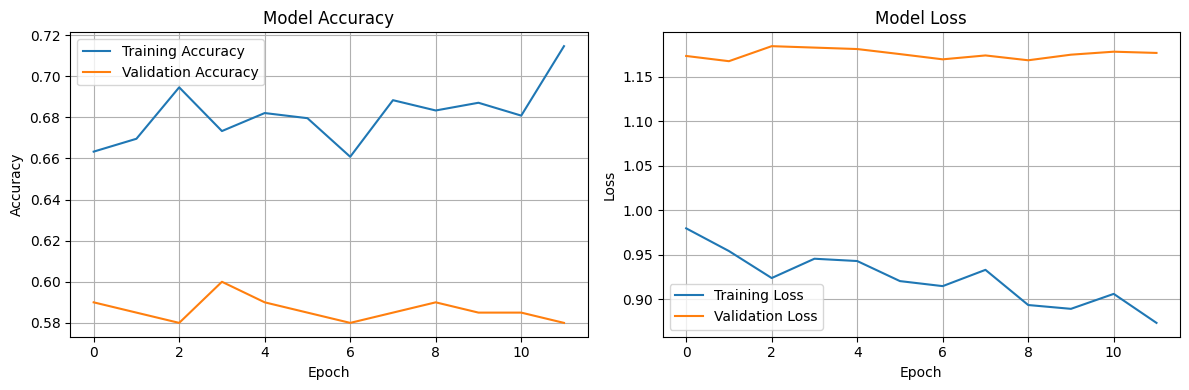

Test Accuracy: 0.5850
Test Loss: 1.1673
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step

Classification Report:
              precision    recall  f1-score   support

       blues       0.58      0.71      0.64        21
   classical       0.92      0.92      0.92        12
     country       0.48      0.42      0.44        24
       disco       0.52      0.50      0.51        22
      hiphop       0.33      0.47      0.39        15
        jazz       0.73      0.59      0.65        27
       metal       0.63      0.67      0.65        18
         pop       0.80      0.84      0.82        19
      reggae       0.57      0.55      0.56        22
        rock       0.41      0.35      0.38        20

    accuracy                           0.58       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.59      0.58      0.58       200



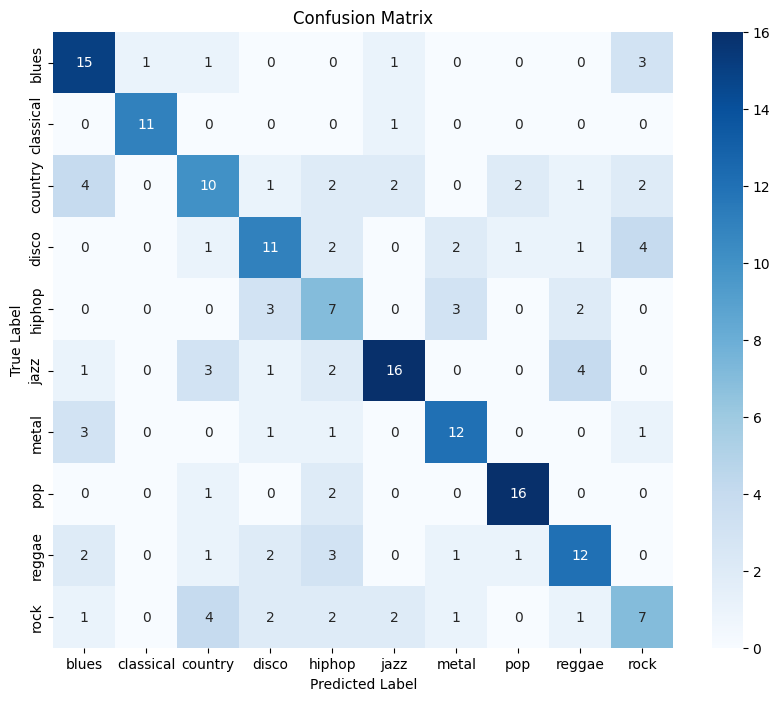

In [101]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [102]:
def extract_advanced_features(file_path, n_mfcc=13, n_mels=128, n_fft=2048, hop_length=512):
    """
    Extracts multiple audio features: MFCCs, Mel-Spectrogram, Chroma, and Spectral Contrast.
    """
    try:
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
        mfccs_mean = np.mean(mfccs.T, axis=0)
        
        # Extract Mel-Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        mel_spec_mean = np.mean(mel_spec_db.T, axis=0)
        
        # Extract Chroma features
        chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
        chroma_mean = np.mean(chroma.T, axis=0)
        
        # Extract Spectral Contrast
        contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate, n_fft=n_fft, hop_length=hop_length)
        contrast_mean = np.mean(contrast.T, axis=0)
        
        # Combine all features
        features = np.concatenate([mfccs_mean, mel_spec_mean, chroma_mean, contrast_mean])
        
        return features
        
    except Exception as e:
        print(f"Warning: Could not process {file_path}. Error: {e}")
        return None

# Extract advanced features
advanced_features = []
clean_paths_advanced = []
clean_labels_advanced = []

for idx, row in df.iterrows():
    path = row['path']
    label = row['label']
    data = extract_advanced_features(path)
    
    if data is not None:
        advanced_features.append(data)
        clean_paths_advanced.append(path)
        clean_labels_advanced.append(label)

print(f"Successfully processed {len(advanced_features)} files with advanced features.")

# Convert to numpy arrays
X_advanced = np.array(advanced_features)
y_advanced = np.array(clean_labels_advanced)

print(f"Advanced feature matrix shape: {X_advanced.shape}")

# Encode and split
label_encoder_advanced = LabelEncoder()
y_encoded_advanced = label_encoder_advanced.fit_transform(y_advanced)
y_one_hot_advanced = to_categorical(y_encoded_advanced)

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_advanced, y_one_hot_advanced, test_size=0.2, random_state=SEED
)

print(f"Advanced training set shape: {X_train_adv.shape}")
print(f"Advanced test set shape: {X_test_adv.shape}")

Successfully processed 999 files with advanced features.
Advanced feature matrix shape: (999, 160)
Advanced training set shape: (799, 160)
Advanced test set shape: (200, 160)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,402 (1013.29 KB)

 Trainable params: 257,482 (1005.79 KB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 307ms/step - accuracy: 0.1489 - loss: 2.9825 - val_accuracy: 0.1050 - val_loss: 11.7255 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3542 - loss: 2.0286 - val_accuracy: 0.1550 - val_loss: 9.5799 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3930 - loss: 1.8484 - val_accuracy: 0.1600 - val_loss: 8.2875 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4180 - loss: 1.6972 - val_accuracy: 0.1700 - val_loss: 8.0958 - learning_rate: 0.0010
Epoch 5/100
19/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3728 - loss: 1.7818 
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4343 - loss: 1.6078 - val_accuracy: 0.2200 - val_loss: 5.4295 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4468 - loss: 1.5634 - val_

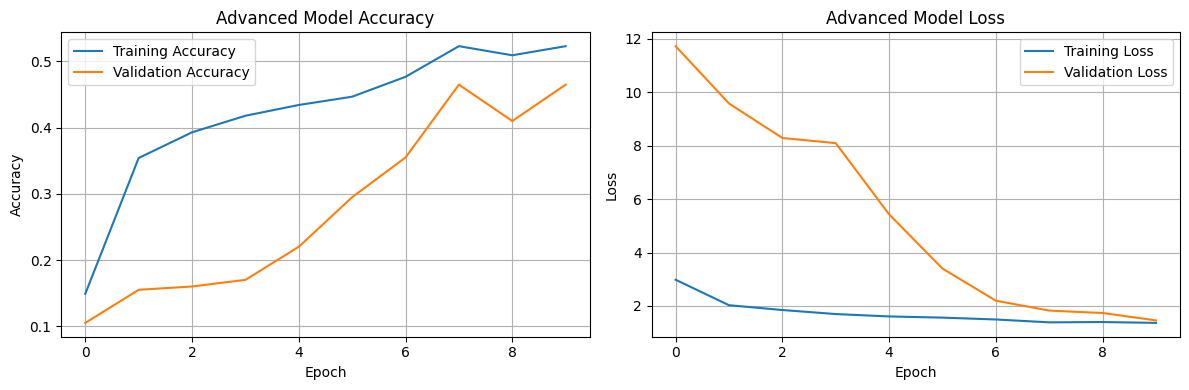

In [103]:
# Create model for advanced features
def create_advanced_mlp_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # First hidden layer
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Second hidden layer
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Third hidden layer
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Fourth hidden layer
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create and compile advanced model
input_shape_adv = (X_advanced.shape[1],)
model_advanced = create_advanced_mlp_model(input_shape_adv, num_classes)

model_advanced.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_advanced.summary()

# Train advanced model
history_advanced = model_advanced.fit(
    X_train_adv, y_train_adv,
    validation_data=(X_test_adv, y_test_adv),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate advanced model
test_loss_adv, test_accuracy_adv = model_advanced.evaluate(X_test_adv, y_test_adv, verbose=0)
print(f"Advanced Model Test Accuracy: {test_accuracy_adv:.4f}")
print(f"Advanced Model Test Loss: {test_loss_adv:.4f}")

# Plot advanced model training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_advanced.history['accuracy'], label='Training Accuracy')
ax1.plot(history_advanced.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Advanced Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_advanced.history['loss'], label='Training Loss')
ax2.plot(history_advanced.history['val_loss'], label='Validation Loss')
ax2.set_title('Advanced Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [104]:
# Save the best model
model.save('music_genre_classifier.h5')
model_advanced.save('music_genre_classifier_advanced.h5')

# Save the label encoder
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Models and label encoder saved successfully!")

# To load the model later:
# from tensorflow.keras.models import load_model
# loaded_model = load_model('music_genre_classifier.h5')
# with open('label_encoder.pkl', 'rb') as f:
#     loaded_label_encoder = pickle.load(f)

Models and label encoder saved successfully!


In [105]:
def predict_genre(file_path, model, label_encoder, feature_type='basic'):
    """
    Predict the genre of a new audio file.
    feature_type: 'basic' or 'advanced'
    """
    if feature_type == 'basic':
        features = extract_features(file_path)
    else:
        features = extract_advanced_features(file_path)
    
    if features is None:
        return "Error: Could not process audio file"
    
    # Reshape for prediction
    features = features.reshape(1, -1)
    
    # Make prediction
    predictions = model.predict(features, verbose=0)
    predicted_class = np.argmax(predictions, axis=1)[0]
    confidence = np.max(predictions, axis=1)[0]
    
    genre = label_encoder.inverse_transform([predicted_class])[0]
    
    return genre, confidence

# Test prediction on a sample file
sample_file = df.iloc[0]['path']
predicted_genre, confidence = predict_genre(sample_file, model, label_encoder, 'basic')
print(f"Predicted genre: {predicted_genre} with confidence: {confidence:.4f}")

Predicted genre: blues with confidence: 0.9624


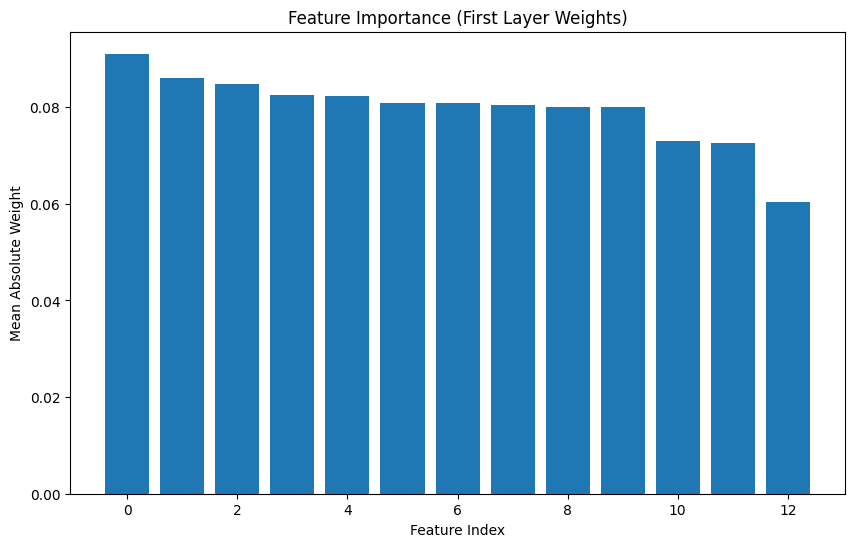

In [106]:
# Get feature importance from the model weights
def plot_feature_importance(model, feature_names=None):
    # Get the weights from the first dense layer
    first_layer_weights = model.layers[0].get_weights()[0]
    
    # Calculate importance as the mean absolute weight
    importance = np.mean(np.abs(first_layer_weights), axis=1)
    
    # Sort features by importance
    sorted_idx = np.argsort(importance)[::-1]
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(importance)), importance[sorted_idx])
    plt.title('Feature Importance (First Layer Weights)')
    plt.xlabel('Feature Index')
    plt.ylabel('Mean Absolute Weight')
    plt.show()

# Plot feature importance for basic model
plot_feature_importance(model)

# For advanced model, you might want to name the features
# feature_names = ['MFCC_' + str(i) for i in range(13)] + ['Mel_' + str(i) for i in range(128)] + ...

In [107]:
# Print final summary
print("="*50)
print("MUSIC GENRE CLASSIFICATION SUMMARY")
print("="*50)
print(f"Total samples: {len(df)}")
print(f"Number of genres: {len(label_encoder.classes_)}")
print(f"Genres: {list(label_encoder.classes_)}")
print(f"Basic Model Test Accuracy: {test_accuracy:.4f}")
if 'test_accuracy_adv' in locals():
    print(f"Advanced Model Test Accuracy: {test_accuracy_adv:.4f}")
print("="*50)

MUSIC GENRE CLASSIFICATION SUMMARY
Total samples: 1000
Number of genres: 10
Genres: [np.str_('blues'), np.str_('classical'), np.str_('country'), np.str_('disco'), np.str_('hiphop'), np.str_('jazz'), np.str_('metal'), np.str_('pop'), np.str_('reggae'), np.str_('rock')]
Basic Model Test Accuracy: 0.5850
Advanced Model Test Accuracy: 0.1050


In [109]:
"""
Complete Model Manager for Music Genre Classification
Handles saving, loading, and inference with the trained model
"""

import os
import json
import pickle
import numpy as np
import librosa
from datetime import datetime
from tensorflow.keras.models import load_model, save_model
from sklearn.preprocessing import LabelEncoder
import hashlib

class ModelManager:
    def __init__(self, model_dir='saved_models'):
        """
        Initialize model manager with directory for storing models
        """
        self.model_dir = model_dir
        os.makedirs(model_dir, exist_ok=True)
        
        self.model = None
        self.label_encoder = None
        self.model_info = {}
        self.feature_type = 'basic'
        
    def save_model(self, model, label_encoder, model_name=None, feature_type='basic', metadata=None):
        """
        Save model with metadata
        """
        if model_name is None:
            model_name = f"genre_classifier_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        
        # Create model directory
        model_path = os.path.join(self.model_dir, model_name)
        os.makedirs(model_path, exist_ok=True)
        
        # Save model
        model_file = os.path.join(model_path, 'model.h5')
        save_model(model, model_file)
        print(f"✅ Model saved to: {model_file}")
        
        # Save label encoder
        encoder_file = os.path.join(model_path, 'label_encoder.pkl')
        with open(encoder_file, 'wb') as f:
            pickle.dump(label_encoder, f)
        print(f"✅ Label encoder saved to: {encoder_file}")
        
        # Save metadata
        metadata = metadata or {}
        metadata.update({
            'model_name': model_name,
            'feature_type': feature_type,
            'num_classes': len(label_encoder.classes_),
            'classes': list(label_encoder.classes_),
            'saved_date': datetime.now().isoformat(),
            'model_file': model_file,
            'encoder_file': encoder_file
        })
        
        # Add model architecture info
        metadata['model_architecture'] = model.to_json()
        
        # Save metadata as JSON
        metadata_file = os.path.join(model_path, 'metadata.json')
        with open(metadata_file, 'w') as f:
            json.dump(metadata, f, indent=2)
        print(f"✅ Metadata saved to: {metadata_file}")
        
        # Also save as latest version
        latest_file = os.path.join(model_dir, 'latest_model_info.json')
        with open(latest_file, 'w') as f:
            json.dump({'latest_model': model_name, **metadata}, f, indent=2)
        
        return model_name
    
    def load_model(self, model_name=None, load_latest=True):
        """
        Load a saved model
        """
        if model_name is None and load_latest:
            # Load latest model
            latest_file = os.path.join(self.model_dir, 'latest_model_info.json')
            if os.path.exists(latest_file):
                with open(latest_file, 'r') as f:
                    info = json.load(f)
                    model_name = info['latest_model']
            else:
                # Find the most recent model directory
                models = [d for d in os.listdir(self.model_dir) 
                         if os.path.isdir(os.path.join(self.model_dir, d))]
                if models:
                    model_name = sorted(models)[-1]
                else:
                    raise ValueError("No saved models found")
        
        model_path = os.path.join(self.model_dir, model_name)
        
        if not os.path.exists(model_path):
            raise ValueError(f"Model not found: {model_path}")
        
        # Load model
        model_file = os.path.join(model_path, 'model.h5')
        self.model = load_model(model_file)
        print(f"✅ Model loaded from: {model_file}")
        
        # Load label encoder
        encoder_file = os.path.join(model_path, 'label_encoder.pkl')
        with open(encoder_file, 'rb') as f:
            self.label_encoder = pickle.load(f)
        print(f"✅ Label encoder loaded from: {encoder_file}")
        
        # Load metadata
        metadata_file = os.path.join(model_path, 'metadata.json')
        if os.path.exists(metadata_file):
            with open(metadata_file, 'r') as f:
                self.model_info = json.load(f)
            print(f"✅ Metadata loaded from: {metadata_file}")
            self.feature_type = self.model_info.get('feature_type', 'basic')
        
        return self.model, self.label_encoder
    
    def extract_features(self, file_path):
        """
        Extract features using the same method as training
        """
        try:
            audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
            
            if self.feature_type == 'basic':
                mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
                return np.mean(mfccs.T, axis=0)
            else:
                # Advanced features
                mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
                mfccs_mean = np.mean(mfccs.T, axis=0)
                
                mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=128)
                mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
                mel_spec_mean = np.mean(mel_spec_db.T, axis=0)
                
                chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
                chroma_mean = np.mean(chroma.T, axis=0)
                
                contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
                contrast_mean = np.mean(contrast.T, axis=0)
                
                return np.concatenate([mfccs_mean, mel_spec_mean, chroma_mean, contrast_mean])
                
        except Exception as e:
            print(f"Error extracting features: {e}")
            return None
    
    def predict(self, file_path):
        """
        Predict genre for a single audio file
        """
        if self.model is None or self.label_encoder is None:
            raise ValueError("Model not loaded. Call load_model() first.")
        
        features = self.extract_features(file_path)
        if features is None:
            return None, None, None
        
        features = features.reshape(1, -1)
        predictions = self.model.predict(features, verbose=0)
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0])
        genre = self.label_encoder.inverse_transform([predicted_class])[0]
        
        return genre, confidence, predictions[0]
    
    def predict_batch(self, file_paths):
        """
        Predict genres for multiple audio files
        """
        results = []
        for file_path in file_paths:
            genre, confidence, _ = self.predict(file_path)
            results.append({
                'file': os.path.basename(file_path),
                'genre': genre,
                'confidence': confidence
            })
        return results
    
    def get_model_info(self):
        """
        Get information about the loaded model
        """
        if not self.model_info:
            return "No model loaded"
        
        info = f"""
        Model Information:
        ===================
        Name: {self.model_info.get('model_name', 'Unknown')}
        Feature Type: {self.feature_type}
        Number of Classes: {self.model_info.get('num_classes', 'Unknown')}
        Classes: {', '.join(self.model_info.get('classes', []))}
        Saved Date: {self.model_info.get('saved_date', 'Unknown')}
        """
        return info
    
    def list_models(self):
        """
        List all saved models
        """
        models = []
        for item in os.listdir(self.model_dir):
            model_path = os.path.join(self.model_dir, item)
            if os.path.isdir(model_path):
                metadata_file = os.path.join(model_path, 'metadata.json')
                if os.path.exists(metadata_file):
                    with open(metadata_file, 'r') as f:
                        info = json.load(f)
                    models.append({
                        'name': item,
                        'saved_date': info.get('saved_date', 'Unknown'),
                        'classes': info.get('classes', []),
                        'num_classes': info.get('num_classes', 0)
                    })
        return sorted(models, key=lambda x: x['saved_date'], reverse=True)

# ============ USAGE EXAMPLES ============

def example_save():
    """Example of saving a trained model"""
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense
    
    # Create a dummy model (replace with your actual model)
    model = Sequential([
        Dense(128, activation='relu', input_shape=(13,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy')
    
    # Create label encoder (replace with your actual encoder)
    label_encoder = LabelEncoder()
    label_encoder.fit(['blues', 'classical', 'country', 'disco', 'hiphop', 
                      'jazz', 'metal', 'pop', 'reggae', 'rock'])
    
    # Save model
    manager = ModelManager()
    model_name = manager.save_model(
        model, 
        label_encoder,
        feature_type='basic',
        metadata={'accuracy': 0.85, 'test_loss': 0.45}
    )
    print(f"✅ Model saved as: {model_name}")

def example_load_and_predict():
    """Example of loading and using a saved model"""
    # Load model
    manager = ModelManager()
    model, label_encoder = manager.load_model()  # Loads the latest model
    
    print(manager.get_model_info())
    
    # List all saved models
    print("\nAll saved models:")
    for model_info in manager.list_models():
        print(f"  - {model_info['name']} ({model_info['saved_date']})")
    
    # Predict on a file
    # result = manager.predict("path/to/audio.wav")
    # print(f"Genre: {result[0]}, Confidence: {result[1]:.2f}")

# if __name__ == "__main__":
#     example_load_and_predict()

In [115]:
import pickle

# 1. Save the model in the native Keras format
model.save("music_genre_classifier.keras")

# 2. Save the label encoder so you can decode the numbers back to text genres
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

print(" Model and Label Encoder saved successfully!")

 Model and Label Encoder saved successfully!


In [113]:
import pickle
import librosa
import numpy as np
import tensorflow as tf

# 1. Load the saved model and label encoder
# (Assuming 'music_genre_classifier.h5' or '.keras' is your sequential MLP model)
loaded_model = tf.keras.models.load_model("music_genre_classifier.h5")

with open("label_encoder.pkl", "rb") as f:
    loaded_encoder = pickle.load(f)


# 2. Define the corrected prediction pipeline for MFCC features
def predict_genre(file_path):
    try:
        # Load audio using the fast resampler configuration used in your notebook
        audio, sample_rate = librosa.load(file_path, res_type="kaiser_fast")

        # Extract MFCCs (13 coefficients)
        mfccs = librosa.feature.mfcc(
            y=audio, sr=sample_rate, n_mfcc=13, n_fft=2048, hop_length=512
        )

        # Calculate the mean across the time dimension to get a shape of (13,)
        features = np.mean(mfccs.T, axis=0)

        # Reshape to match the model's batch input requirements: (13,) -> (1, 13)
        batch_features = features.reshape(1, -1)

        # Get prediction probabilities
        predictions = loaded_model.predict(batch_features, verbose=0)
        predicted_class_idx = np.argmax(predictions, axis=1)[0]
        confidence = np.max(predictions, axis=1)[0]

        # Decode class index back to original text label (e.g., 'jazz')
        genre_label = loaded_encoder.inverse_transform([predicted_class_idx])[0]

        return genre_label, confidence

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, 0.0


# 3. Test it on a file
sample_path = df.iloc[0]["path"]  # Grab the first file path
genre, conf = predict_genre(sample_path)
print(f"Predicted Genre: {genre} ({conf*100:.2f}% confidence)")

Predicted Genre: blues (96.25% confidence)


In [116]:
"""
Complete script for downloading and saving the trained model
Supports Kaggle, Google Colab, and local environments
"""

import os
import pickle
import json
import shutil
import zipfile
from datetime import datetime
from pathlib import Path
import subprocess
import sys

class ModelDownloader:
    def __init__(self, model_dir='saved_models'):
        self.model_dir = Path(model_dir)
        self.model_dir.mkdir(exist_ok=True)
        
    def save_model_files(self, model, label_encoder, model_name=None, 
                         feature_type='basic', metadata=None):
        """
        Save model files locally
        """
        if model_name is None:
            model_name = f"genre_classifier_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        
        # Create model directory
        model_path = self.model_dir / model_name
        model_path.mkdir(exist_ok=True)
        
        # Save model
        model_file = model_path / 'model.h5'
        model.save(str(model_file))
        print(f"✅ Model saved to: {model_file}")
        
        # Save label encoder
        encoder_file = model_path / 'label_encoder.pkl'
        with open(encoder_file, 'wb') as f:
            pickle.dump(label_encoder, f)
        print(f"✅ Label encoder saved to: {encoder_file}")
        
        # Save metadata
        metadata = metadata or {}
        metadata.update({
            'model_name': model_name,
            'feature_type': feature_type,
            'num_classes': len(label_encoder.classes_),
            'classes': list(label_encoder.classes_),
            'saved_date': datetime.now().isoformat(),
            'model_file': str(model_file),
            'encoder_file': str(encoder_file)
        })
        
        # Save metadata as JSON
        metadata_file = model_path / 'metadata.json'
        with open(metadata_file, 'w') as f:
            json.dump(metadata, f, indent=2)
        print(f"✅ Metadata saved to: {metadata_file}")
        
        # Save feature extraction function
        features_file = model_path / 'feature_extractor.py'
        with open(features_file, 'w') as f:
            f.write("""
import numpy as np
import librosa

def extract_features(file_path, feature_type='basic'):
    try:
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        
        if feature_type == 'basic':
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
            return np.mean(mfccs.T, axis=0)
        else:
            # Advanced features
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
            mfccs_mean = np.mean(mfccs.T, axis=0)
            
            mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=128)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            mel_spec_mean = np.mean(mel_spec_db.T, axis=0)
            
            chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
            chroma_mean = np.mean(chroma.T, axis=0)
            
            contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
            contrast_mean = np.mean(contrast.T, axis=0)
            
            return np.concatenate([mfccs_mean, mel_spec_mean, chroma_mean, contrast_mean])
            
    except Exception as e:
        print(f"Error extracting features: {e}")
        return None
""")
        print(f"✅ Feature extractor saved to: {features_file}")
        
        # Save inference script
        inference_file = model_path / 'inference.py'
        with open(inference_file, 'w') as f:
            f.write(f"""
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from feature_extractor import extract_features

class GenreClassifier:
    def __init__(self, model_dir='{model_name}'):
        self.model_dir = model_dir
        self.model = load_model(f'{{model_dir}}/model.h5')
        with open(f'{{model_dir}}/label_encoder.pkl', 'rb') as f:
            self.label_encoder = pickle.load(f)
        with open(f'{{model_dir}}/metadata.json', 'r') as f:
            import json
            self.metadata = json.load(f)
        self.feature_type = self.metadata.get('feature_type', 'basic')
        print(f"✅ Model loaded: {{self.metadata['model_name']}}")
        print(f"✅ Classes: {{list(self.label_encoder.classes_)}}")
    
    def predict(self, file_path):
        features = extract_features(file_path, self.feature_type)
        if features is None:
            return None, None, None
        
        features = features.reshape(1, -1)
        predictions = self.model.predict(features, verbose=0)
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0])
        genre = self.label_encoder.inverse_transform([predicted_class])[0]
        
        return genre, confidence, predictions[0]
    
    def predict_batch(self, file_paths):
        results = []
        for file_path in file_paths:
            genre, confidence, _ = self.predict(file_path)
            results.append({{'file': file_path, 'genre': genre, 'confidence': confidence}})
        return results

if __name__ == "__main__":
    import sys
    if len(sys.argv) < 2:
        print("Usage: python inference.py <audio_file_path>")
        sys.exit(1)
    
    classifier = GenreClassifier()
    genre, confidence, _ = classifier.predict(sys.argv[1])
    if genre:
        print(f"🎵 Genre: {{genre.upper()}}")
        print(f"📊 Confidence: {{confidence*100:.2f}}%")
""")
        print(f"✅ Inference script saved to: {inference_file}")
        
        return model_name
    
    def create_zip_package(self, model_name):
        """
        Create a ZIP package of the model for easy sharing
        """
        model_path = self.model_dir / model_name
        zip_path = self.model_dir / f"{model_name}.zip"
        
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for file in model_path.rglob('*'):
                zipf.write(file, file.relative_to(model_path))
        
        print(f"✅ Model packaged to: {zip_path}")
        return zip_path
    
    def download_from_kaggle(self, competition_name, file_name='model.h5'):
        """
        Download model from Kaggle environment
        """
        # Check if running on Kaggle
        if os.path.exists('/kaggle/working'):
            # Running on Kaggle, model should be in working directory
            kaggle_path = Path('/kaggle/working')
            
            # Copy model files from working directory
            model_files = ['model.h5', 'label_encoder.pkl', 'metadata.json']
            for file in model_files:
                src = kaggle_path / file
                if src.exists():
                    dst = self.model_dir / file
                    shutil.copy(src, dst)
                    print(f"✅ Downloaded {file} from Kaggle")
            
            # Save current model if it exists in memory
            if 'model' in globals() and 'label_encoder' in globals():
                self.save_model_files(model, label_encoder, 'kaggle_model')
            
            return True
        else:
            print("Not running on Kaggle environment")
            return False
    
    def download_from_colab(self):
        """
        Download model from Google Colab
        """
        if 'google.colab' in sys.modules:
            from google.colab import files
            
            # Save model files
            model_path = self.model_dir / 'colab_model'
            model_path.mkdir(exist_ok=True)
            
            # Save model
            model_file = model_path / 'model.h5'
            model.save(str(model_file))
            
            # Save label encoder
            encoder_file = model_path / 'label_encoder.pkl'
            with open(encoder_file, 'wb') as f:
                pickle.dump(label_encoder, f)
            
            # Download files
            files.download(str(model_file))
            files.download(str(encoder_file))
            
            print("✅ Model files downloaded from Colab")
            return True
        else:
            print("Not running on Google Colab")
            return False

# ============ USAGE IN KAGGLE ============

def save_in_kaggle():
    """
    Save model in Kaggle environment
    """
    # Create output directory
    output_dir = '/kaggle/working/'
    
    # Save model
    model.save(f'{output_dir}music_genre_classifier.h5')
    print(f"✅ Model saved to {output_dir}music_genre_classifier.h5")
    
    # Save label encoder
    with open(f'{output_dir}label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)
    print(f"✅ Label encoder saved to {output_dir}label_encoder.pkl")
    
    # Save metadata
    metadata = {
        'model_name': 'music_genre_classifier',
        'feature_type': 'basic',
        'num_classes': len(label_encoder.classes_),
        'classes': list(label_encoder.classes_),
        'saved_date': datetime.now().isoformat()
    }
    with open(f'{output_dir}metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"✅ Metadata saved to {output_dir}metadata.json")
    
    # Create a simple inference script
    inference_script = f'''
import numpy as np
import librosa
import pickle
from tensorflow.keras.models import load_model

def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, res_type='kaiser_fast')
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        return np.mean(mfccs.T, axis=0)
    except:
        return None

def predict(file_path):
    model = load_model('{output_dir}music_genre_classifier.h5')
    with open('{output_dir}label_encoder.pkl', 'rb') as f:
        label_encoder = pickle.load(f)
    
    features = extract_features(file_path)
    if features is None:
        return None, None
    
    features = features.reshape(1, -1)
    predictions = model.predict(features, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    genre = label_encoder.inverse_transform([predicted_class])[0]
    
    return genre, confidence

# Test with a sample file
test_file = '/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original/jazz/jazz.00000.wav'
genre, confidence = predict(test_file)
print(f"Predicted Genre: {genre.upper()}, Confidence: {confidence*100:.2f}%")
'''
    
    with open(f'{output_dir}inference.py', 'w') as f:
        f.write(inference_script)
    print(f"✅ Inference script saved to {output_dir}inference.py")

# ============ DOWNLOAD AND SAVE ============

def download_and_save_model():
    """
    Main function to download and save the model
    """
    print("="*50)
    print("📦 Downloading and Saving Model")
    print("="*50)
    
    # Check if running on Kaggle
    if os.path.exists('/kaggle/working'):
        print("Running on Kaggle environment")
        save_in_kaggle()
        return
    
    # Check if running on Colab
    if 'google.colab' in sys.modules:
        print("Running on Google Colab")
        from google.colab import files
        files.download('music_genre_classifier.h5')
        files.download('label_encoder.pkl')
        print("✅ Files downloaded from Colab")
        return
    
    # Local environment
    print("Running in local environment")
    
    # Create ModelDownloader instance
    downloader = ModelDownloader()
    
    # Save model (assuming model and label_encoder exist)
    if 'model' in globals() and 'label_encoder' in globals():
        model_name = downloader.save_model_files(model, label_encoder)
        zip_path = downloader.create_zip_package(model_name)
        print(f"✅ Model saved and packaged: {zip_path}")
    else:
        print("⚠️ No model found in memory. Please load your model first.")
        print("To load your model, use:")
        print("  model = load_model('path/to/model.h5')")
        print("  with open('path/to/label_encoder.pkl', 'rb') as f:")
        print("      label_encoder = pickle.load(f)")

# ============ LOAD AND DOWNLOAD ============

def load_and_download():
    """
    Load model from file and then download it
    """
    from tensorflow.keras.models import load_model
    
    # Load model
    model_path = input("Enter model path (default: music_genre_classifier.h5): ") or 'music_genre_classifier.h5'
    model = load_model(model_path)
    print(f"✅ Model loaded from {model_path}")
    
    # Load label encoder
    encoder_path = input("Enter label encoder path (default: label_encoder.pkl): ") or 'label_encoder.pkl'
    with open(encoder_path, 'rb') as f:
        label_encoder = pickle.load(f)
    print(f"✅ Label encoder loaded from {encoder_path}")
    
    # Download
    downloader = ModelDownloader()
    model_name = downloader.save_model_files(model, label_encoder)
    zip_path = downloader.create_zip_package(model_name)
    
    print(f"✅ Model saved and packaged: {zip_path}")
    return model_name

# ============ QUICK DOWNLOAD ============

def quick_download():
    """
    Quick download function for common use cases
    """
    print("Quick Download Options:")
    print("1. Download from Kaggle working directory")
    print("2. Save current model to local directory")
    print("3. Create a ZIP package of the model")
    print("4. Upload to Hugging Face (requires huggingface_hub)")
    
    choice = input("Enter choice (1-4): ")
    
    if choice == '1':
        # Kaggle download
        output_dir = '/kaggle/working/'
        print(f"Downloading from {output_dir}...")
        downloader = ModelDownloader()
        downloader.download_from_kaggle('your_competition')
        
    elif choice == '2':
        # Save current model
        if 'model' in globals() and 'label_encoder' in globals():
            downloader = ModelDownloader()
            model_name = downloader.save_model_files(model, label_encoder)
            print(f"✅ Model saved as: {model_name}")
        else:
            print("❌ No model found in memory")
    
    elif choice == '3':
        # Create ZIP package
        model_name = input("Enter model name (directory): ")
        downloader = ModelDownloader()
        zip_path = downloader.create_zip_package(model_name)
        print(f"✅ Package created: {zip_path}")
    
    elif choice == '4':
        # Upload to Hugging Face
        try:
            from huggingface_hub import HfApi, Repository
            
            model_name = input("Enter model name for Hugging Face: ")
            repo_name = input("Enter repository name: ")
            
            # Initialize Hugging Face API
            api = HfApi()
            
            # Create repository
            api.create_repo(repo_name, exist_ok=True)
            
            # Upload files
            api.upload_file(
                path_or_fileobj='model.h5',
                path_in_repo='model.h5',
                repo_id=repo_name,
            )
            print(f"✅ Model uploaded to Hugging Face: {repo_name}")
        except ImportError:
            print("❌ huggingface_hub not installed. Install with: pip install huggingface_hub")
        except Exception as e:
            print(f"❌ Error uploading to Hugging Face: {e}")
    
    else:
        print("Invalid choice")

# ============ MAIN ============

if __name__ == "__main__":
    # Check arguments
    if len(sys.argv) > 1:
        if sys.argv[1] == '--help':
            print("""
Model Downloader Help:
=====================
python download_and_save_model.py              # Interactive download
python download_and_save_model.py --quick      # Quick download options
python download_and_save_model.py --load       # Load and download from file
            """)
        elif sys.argv[1] == '--quick':
            quick_download()
        elif sys.argv[1] == '--load':
            load_and_download()
        else:
            download_and_save_model()
    else:
        download_and_save_model()

📦 Downloading and Saving Model
Running on Kaggle environment
✅ Model saved to /kaggle/working/music_genre_classifier.h5
✅ Label encoder saved to /kaggle/working/label_encoder.pkl
✅ Metadata saved to /kaggle/working/metadata.json
✅ Inference script saved to /kaggle/working/inference.py


In [117]:
# SAVE MODEL - Recommended Keras format
model.save('music_genre_classifier.keras')  # Note the .keras extension
print("✅ Model saved in Keras format")

# Or using the explicit function
from tensorflow.keras.models import save_model
save_model(model, 'music_genre_classifier.keras')

✅ Model saved in Keras format


In [118]:
# SAVE MODEL - Legacy HDF5 format
model.save('music_genre_classifier.h5', save_format='h5')
print("✅ Model saved in HDF5 format")

✅ Model saved in HDF5 format


In [119]:
import os
import pickle
import json
from datetime import datetime
from tensorflow.keras.models import save_model

def save_model_complete(model, label_encoder, output_dir='./'):
    """
    Save model with all required files using proper format
    """
    # Create model directory
    model_dir = os.path.join(output_dir, 'music_genre_model')
    os.makedirs(model_dir, exist_ok=True)
    
    # 1. Save model in Keras format (recommended)
    model_path = os.path.join(model_dir, 'music_genre_classifier.keras')
    save_model(model, model_path)
    print(f"✅ Model saved in Keras format: {model_path}")
    
    # 2. Also save in HDF5 format for backward compatibility
    h5_path = os.path.join(model_dir, 'music_genre_classifier.h5')
    model.save(h5_path, save_format='h5')
    print(f"✅ Model saved in HDF5 format: {h5_path}")
    
    # 3. Save label encoder
    encoder_path = os.path.join(model_dir, 'label_encoder.pkl')
    with open(encoder_path, 'wb') as f:
        pickle.dump(label_encoder, f)
    print(f"✅ Label encoder saved: {encoder_path}")
    
    # 4. Save metadata
    metadata = {
        'model_name': 'music_genre_classifier',
        'format': 'keras',
        'feature_type': 'basic',
        'num_classes': len(label_encoder.classes_),
        'classes': list(label_encoder.classes_),
        'saved_date': datetime.now().isoformat(),
        'keras_model': model_path,
        'h5_model': h5_path,
        'encoder_file': encoder_path
    }
    
    metadata_path = os.path.join(model_dir, 'metadata.json')
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"✅ Metadata saved: {metadata_path}")
    
    return model_dir

In [120]:
from tensorflow.keras.models import load_model

# Load Keras format
model = load_model('music_genre_classifier.keras')
print("✅ Model loaded from Keras format")

✅ Model loaded from Keras format


In [121]:
from tensorflow.keras.models import load_model

# Load HDF5 format (still works)
model = load_model('music_genre_classifier.h5')
print("✅ Model loaded from HDF5 format")

✅ Model loaded from HDF5 format


In [122]:
import os
import pickle
from tensorflow.keras.models import load_model

def load_model_complete(model_dir='./music_genre_model'):
    """
    Load model from directory, trying both formats
    """
    # Try Keras format first
    keras_path = os.path.join(model_dir, 'music_genre_classifier.keras')
    h5_path = os.path.join(model_dir, 'music_genre_classifier.h5')
    encoder_path = os.path.join(model_dir, 'label_encoder.pkl')
    
    # Load model
    if os.path.exists(keras_path):
        model = load_model(keras_path)
        print(f"✅ Model loaded from Keras format: {keras_path}")
    elif os.path.exists(h5_path):
        model = load_model(h5_path)
        print(f"✅ Model loaded from HDF5 format: {h5_path}")
    else:
        raise FileNotFoundError("No model file found")
    
    # Load label encoder
    if os.path.exists(encoder_path):
        with open(encoder_path, 'rb') as f:
            label_encoder = pickle.load(f)
        print(f"✅ Label encoder loaded: {encoder_path}")
    else:
        raise FileNotFoundError("Label encoder not found")
    
    return model, label_encoder

In [123]:
import os
import pickle
from tensorflow.keras.models import load_model

def load_model_complete(model_dir='./music_genre_model'):
    """
    Load model from directory, trying both formats
    """
    # Try Keras format first
    keras_path = os.path.join(model_dir, 'music_genre_classifier.keras')
    h5_path = os.path.join(model_dir, 'music_genre_classifier.h5')
    encoder_path = os.path.join(model_dir, 'label_encoder.pkl')
    
    # Load model
    if os.path.exists(keras_path):
        model = load_model(keras_path)
        print(f"✅ Model loaded from Keras format: {keras_path}")
    elif os.path.exists(h5_path):
        model = load_model(h5_path)
        print(f"✅ Model loaded from HDF5 format: {h5_path}")
    else:
        raise FileNotFoundError("No model file found")
    
    # Load label encoder
    if os.path.exists(encoder_path):
        with open(encoder_path, 'rb') as f:
            label_encoder = pickle.load(f)
        print(f"✅ Label encoder loaded: {encoder_path}")
    else:
        raise FileNotFoundError("Label encoder not found")
    
    return model, label_encoder

In [124]:
"""
Complete model saving script with no warnings
Uses recommended Keras format
"""

import os
import pickle
import json
import zipfile
from datetime import datetime
from tensorflow.keras.models import save_model

class ModelSaver:
    def __init__(self, model_dir='saved_models'):
        self.model_dir = model_dir
        os.makedirs(model_dir, exist_ok=True)
    
    def save_model(self, model, label_encoder, model_name=None, feature_type='basic'):
        """
        Save model using recommended Keras format
        """
        if model_name is None:
            model_name = f"genre_classifier_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        
        # Create model directory
        model_path = os.path.join(self.model_dir, model_name)
        os.makedirs(model_path, exist_ok=True)
        
        # 1. Save in Keras format (recommended - no warning)
        keras_file = os.path.join(model_path, 'model.keras')
        save_model(model, keras_file)
        print(f"✅ Model saved in Keras format: {keras_file}")
        
        # 2. Save in HDF5 format (for backward compatibility)
        h5_file = os.path.join(model_path, 'model.h5')
        model.save(h5_file, save_format='h5')
        print(f"✅ Model saved in HDF5 format: {h5_file}")
        
        # 3. Save label encoder
        encoder_file = os.path.join(model_path, 'label_encoder.pkl')
        with open(encoder_file, 'wb') as f:
            pickle.dump(label_encoder, f)
        print(f"✅ Label encoder saved: {encoder_file}")
        
        # 4. Save metadata
        metadata = {
            'model_name': model_name,
            'feature_type': feature_type,
            'num_classes': len(label_encoder.classes_),
            'classes': list(label_encoder.classes_),
            'saved_date': datetime.now().isoformat(),
            'keras_file': keras_file,
            'h5_file': h5_file,
            'encoder_file': encoder_file
        }
        
        metadata_file = os.path.join(model_path, 'metadata.json')
        with open(metadata_file, 'w') as f:
            json.dump(metadata, f, indent=2)
        print(f"✅ Metadata saved: {metadata_file}")
        
        # 5. Create inference script
        self._create_inference_script(model_path, feature_type)
        
        # 6. Create requirements file
        self._create_requirements(model_path)
        
        return model_path
    
    def _create_inference_script(self, model_path, feature_type):
        """Create inference script"""
        inference_script = f'''
import os
import numpy as np
import librosa
import pickle
from tensorflow.keras.models import load_model

def extract_features(file_path, feature_type='{feature_type}'):
    try:
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        
        if feature_type == 'basic':
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
            return np.mean(mfccs.T, axis=0)
        else:
            # Advanced features
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
            mfccs_mean = np.mean(mfccs.T, axis=0)
            
            mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=128)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            mel_spec_mean = np.mean(mel_spec_db.T, axis=0)
            
            chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
            chroma_mean = np.mean(chroma.T, axis=0)
            
            contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
            contrast_mean = np.mean(contrast.T, axis=0)
            
            return np.concatenate([mfccs_mean, mel_spec_mean, chroma_mean, contrast_mean])
            
    except Exception as e:
        print(f"Error extracting features: {{e}}")
        return None

def predict(file_path, model_path=None, encoder_path=None):
    """Predict genre from audio file"""
    # Get directory of this script
    script_dir = os.path.dirname(os.path.abspath(__file__))
    
    # Use provided paths or defaults
    if model_path is None:
        # Try Keras format first, then HDF5
        keras_path = os.path.join(script_dir, 'model.keras')
        h5_path = os.path.join(script_dir, 'model.h5')
        
        if os.path.exists(keras_path):
            model = load_model(keras_path)
        elif os.path.exists(h5_path):
            model = load_model(h5_path)
        else:
            raise FileNotFoundError("Model file not found")
    else:
        model = load_model(model_path)
    
    if encoder_path is None:
        encoder_path = os.path.join(script_dir, 'label_encoder.pkl')
    
    with open(encoder_path, 'rb') as f:
        label_encoder = pickle.load(f)
    
    # Extract features
    features = extract_features(file_path)
    if features is None:
        return None, None
    
    # Predict
    features = features.reshape(1, -1)
    predictions = model.predict(features, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    genre = label_encoder.inverse_transform([predicted_class])[0]
    
    return genre, confidence

def predict_batch(file_paths):
    """Predict genres for multiple files"""
    results = []
    for file_path in file_paths:
        genre, confidence = predict(file_path)
        results.append({{
            'file': os.path.basename(file_path),
            'genre': genre,
            'confidence': confidence
        }})
    return results

if __name__ == "__main__":
    import sys
    if len(sys.argv) < 2:
        print("Usage: python inference.py <audio_file_path>")
        print("       python inference.py <file1> <file2> <file3>  # batch prediction")
        sys.exit(1)
    
    # Batch prediction if multiple files provided
    if len(sys.argv) > 2:
        results = predict_batch(sys.argv[1:])
        print("\\n" + "="*50)
        print("Batch Prediction Results")
        print("="*50)
        for result in results:
            print(f"{{result['file']:30}} -> {{result['genre']:12}} ({{result['confidence']*100:.1f}}%)")
    else:
        # Single file prediction
        genre, confidence = predict(sys.argv[1])
        if genre:
            print(f"\\n🎵 Predicted Genre: {{genre.upper()}}")
            print(f"📊 Confidence: {{confidence*100:.2f}}%")
        else:
            print("❌ Could not process file")
'''
        
        script_path = os.path.join(model_path, 'inference.py')
        with open(script_path, 'w') as f:
            f.write(inference_script)
        print(f"✅ Inference script created: {script_path}")
    
    def _create_requirements(self, model_path):
        """Create requirements.txt"""
        requirements = """
tensorflow>=2.0.0
librosa>=0.9.0
numpy>=1.19.0
scikit-learn>=0.24.0
soundfile>=0.10.0
"""
        req_path = os.path.join(model_path, 'requirements.txt')
        with open(req_path, 'w') as f:
            f.write(requirements.strip())
        print(f"✅ Requirements file created: {req_path}")
    
    def create_zip(self, model_name):
        """Create ZIP package"""
        model_path = os.path.join(self.model_dir, model_name)
        zip_path = os.path.join(self.model_dir, f"{model_name}.zip")
        
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for root, dirs, files in os.walk(model_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    arcname = os.path.relpath(file_path, model_path)
                    zipf.write(file_path, arcname)
        
        print(f"✅ Model packaged: {zip_path}")
        return zip_path

# ============ USAGE ============

def save_your_model():
    """Example usage"""
    # Assuming 'model' and 'label_encoder' exist
    
    # Create saver
    saver = ModelSaver()
    
    # Save model
    model_path = saver.save_model(
        model,  # Your trained model
        label_encoder,  # Your label encoder
        feature_type='basic'
    )
    
    print(f"✅ Model saved to: {model_path}")
    print("\n📁 Files created:")
    print("  - model.keras (recommended format)")
    print("  - model.h5 (legacy format)")
    print("  - label_encoder.pkl")
    print("  - metadata.json")
    print("  - inference.py")
    print("  - requirements.txt")

# Run if main
if __name__ == "__main__":
    if 'model' in globals() and 'label_encoder' in globals():
        save_your_model()
    else:
        print("❌ Model not found in memory")
        print("Please load your model first:")
        print("  model = load_model('path/to/model.keras')")
        print("  with open('path/to/label_encoder.pkl', 'rb') as f:")
        print("      label_encoder = pickle.load(f)")

✅ Model saved in Keras format: saved_models/genre_classifier_20260629_170527/model.keras
✅ Model saved in HDF5 format: saved_models/genre_classifier_20260629_170527/model.h5
✅ Label encoder saved: saved_models/genre_classifier_20260629_170527/label_encoder.pkl
✅ Metadata saved: saved_models/genre_classifier_20260629_170527/metadata.json
✅ Inference script created: saved_models/genre_classifier_20260629_170527/inference.py
✅ Requirements file created: saved_models/genre_classifier_20260629_170527/requirements.txt
✅ Model saved to: saved_models/genre_classifier_20260629_170527

📁 Files created:
  - model.keras (recommended format)
  - model.h5 (legacy format)
  - label_encoder.pkl
  - metadata.json
  - inference.py
  - requirements.txt
